# Fragmentation & tract-length fidelity

Downstream admixture-pulse dating reads the **segment-length distribution**, so spurious short
opposite-ancestry calls (fragmenting a long tract) bias the inferred pulse *older*. Naive
`argmax` of the posterior over-fragments; a confidence **deadband** on the calibrated posterior
([`hard_segments`](../api/output.hard_segments.html)) recovers the true distribution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import tspaint
from tspaint.sim import SOURCE_A, SOURCE_B, ADMIXED

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})

def admixture(n_admix=8, n_ref=8, L=2e6, T_admix=100, Ne=1000, T_split=5000, f_A=0.5,
              seed=1, infer=False, mutation_rate=4e-7):
    """Simulate admixture with known truth; return (ts, labels, queries, truth_states)."""
    ts = tspaint.simulate_admixture(n_admix=n_admix, n_ref=n_ref, sequence_length=L,
                                  recombination_rate=1e-8, random_seed=seed, Ne=Ne,
                                  T_admix=T_admix, T_split=T_split, f_A=f_A)
    pop = ts.tables.nodes.population
    name = {p: ts.population(p).metadata.get("name", str(p)) for p in range(ts.num_populations)}
    A = next(p for p, n in name.items() if n == SOURCE_A)
    B = next(p for p, n in name.items() if n == SOURCE_B)
    admix = next(p for p, n in name.items() if n == ADMIXED)
    sop = {A: 0, B: 1}
    labels = {int(s): sop[pop[s]] for s in ts.samples() if pop[s] in (A, B)}
    queries = [int(s) for s in ts.samples() if pop[s] == admix]
    truth = tspaint.metrics.map_truth({q: tspaint.local_ancestry_truth(ts)[0][q] for q in queries}, sop)
    work = ts
    if infer:
        work = tspaint.io.infer_tree_sequence(tspaint.io.add_mutations(ts, rate=mutation_rate,
                                                                   random_seed=seed))
    return work, labels, queries, truth

CMAP = "RdBu_r"   # red = ancestry A (state 0), blue = ancestry B (state 1)

def plot_painting(painting, truth, ts, title="", segments=None):
    """Soft posterior P(A) painted along the genome per query haplotype, with a thin truth
    strip beneath each. If `segments` (hard tracts) is given, draw those instead of soft."""
    qs = painting.queries
    L = ts.sequence_length
    sm = cm.ScalarMappable(norm=colors.Normalize(0, 1), cmap=CMAP)
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(qs) + 1.2))
    for i, q in enumerate(qs):
        if segments is None:
            for seg in painting.posteriors[q]:
                ax.barh(i, seg.right - seg.left, left=seg.left, height=0.74,
                        color=sm.to_rgba(seg.posterior[0]), edgecolor="none")
        else:
            for (l, r, s) in segments[q]:
                ax.barh(i, r - l, left=l, height=0.74,
                        color=sm.to_rgba(1.0 if s == 0 else 0.0), edgecolor="none")
        for (l, r, s) in truth[q]:
            ax.barh(i - 0.46, r - l, left=l, height=0.13,
                    color=sm.to_rgba(1.0 if s == 0 else 0.0), edgecolor="none")
    ax.set_xlim(0, L); ax.set_ylim(-0.8, len(qs) - 0.2)
    ax.set_yticks(range(len(qs))); ax.set_yticklabels([f"hap {q}" for q in qs], fontsize=8)
    ax.set_xlabel("genomic position (bp)"); ax.set_title(title)
    cb = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.01)
    cb.set_label("P(ancestry A)")
    ax.text(0, len(qs) - 0.5, "thin strip below each = true ancestry", fontsize=7, color="0.4")
    fig.tight_layout()
    return fig

## Switch density: argmax vs deadband vs truth

The switch-density ratio (inferred / true) is the dating-relevant quantity: >1 fragments (biases older).

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_84745/2124415312.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


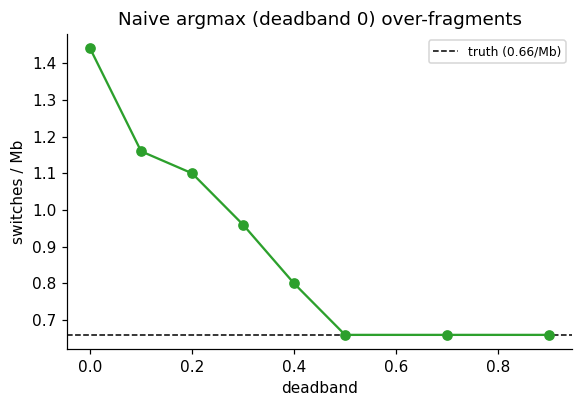

In [2]:
#| label: fig-switchdensity
#| fig-cap: "Inferred switch density vs the deadband: argmax (deadband 0) over-fragments; a modest deadband recovers the true switch density."
import numpy as np
from tspaint.output import hard_segments
from tspaint.metrics import switch_density

ts, labels, queries, truth = admixture(n_admix=10, n_ref=10, L=5e6, T_admix=200, seed=1)
p = tspaint.paint(ts, labels)
L = ts.sequence_length
true_d = np.mean([switch_density(truth[q], L) for q in queries]) * 1e6
def density(db):
    return np.mean([switch_density(hard_segments(p.posteriors[q], db), L) for q in queries]) * 1e6
deadbands = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9]
dens = [density(c) for c in deadbands]
fig, ax = plt.subplots(figsize=(5.4, 3.8))
ax.axhline(true_d, color="k", ls="--", lw=1, label=f"truth ({true_d:.2f}/Mb)")
ax.plot(deadbands, dens, "o-", color="C2")
ax.set_xlabel("deadband"); ax.set_ylabel("switches / Mb")
ax.set_title("Naive argmax (deadband 0) over-fragments"); ax.legend(fontsize=8); fig.tight_layout()
fig.show()

## Tract-length distribution

Histogram of inferred tract lengths (argmax vs deadband) against the truth.

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_84745/2254000448.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


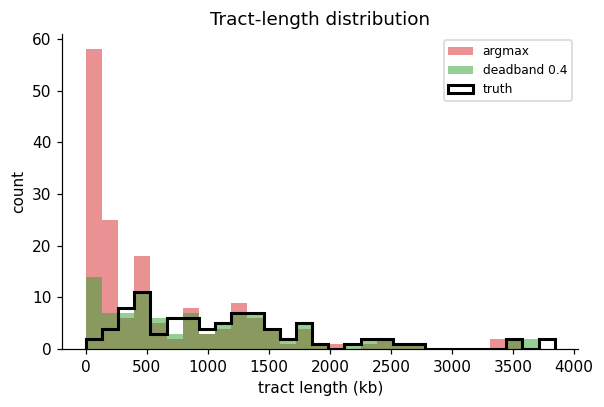

In [3]:
#| label: fig-tractlen
#| fig-cap: "Tract-length distribution: naive argmax produces too many short tracts; the deadband matches the truth."
def lengths(segs_by):
    return np.concatenate([[r - l for (l, r, _s) in segs_by[q]] for q in queries]) / 1e3
tl_true = lengths(truth)
tl_argmax = lengths({q: hard_segments(p.posteriors[q], 0.0) for q in queries})
tl_db = lengths({q: hard_segments(p.posteriors[q], 0.4) for q in queries})
bins = np.linspace(0, max(tl_true.max(), tl_argmax.max()), 30)
fig, ax = plt.subplots(figsize=(5.6, 3.8))
ax.hist(tl_argmax, bins, alpha=0.5, label="argmax", color="C3")
ax.hist(tl_db, bins, alpha=0.5, label="deadband 0.4", color="C2")
ax.hist(tl_true, bins, histtype="step", lw=2, label="truth", color="k")
ax.set_xlabel("tract length (kb)"); ax.set_ylabel("count")
ax.set_title("Tract-length distribution"); ax.legend(fontsize=8); fig.tight_layout()
fig.show()